causa (de ingreso),fecha de atencion y tipo de establecimiento 
con esto se busca poder visualizar la cantidad de registros por cada causa de ingreso, fecha de atencion y tipo de establecimiento donde ingreso el paciente, esto nos permite identificar cuales son las causas de ingreso mas comunes, cuales son las fechas de atencion mas comunes y cuales son los tipos de establecimiento mas comunes, esto nos permite tener una mejor comprension de los datos y poder tomar decisiones sobre como manejar esos datos.

* El manejo de los datos se realizara en 3  visualizaciones de la data correspondiente de cada una de las columnas se trabajaran de forma separada para poder tener una mejor visualizacion de los datos y poder identificar patrones, tendencias y relaciones entre las diferentes variables, esto nos permite tener una mejor comprension de los datos y poder tomar decisiones sobre como manejar esos datos. se dividiran en grupos de 3 los cuales seran:

- nivel de conplejidad, tipo de urgencia y sexo del paciente
- causa de ingreso, fecha de atencion y tipo de establecimiento
- causa de ingreso, tipo de establecimiento y costo de atencion cl



In [1]:
import pandas as pd
df=pd.read_csv('urgencias_noprocesados_grupo02.csv',sep=';')
print(df.head())

   EstablecimientoCodigo                     EstablecimientoGlosa  \
0                 110901  Hospital Regional de Arica Dr. Juan Noe   
1                 110901  Hospital Regional de Arica Dr. Juan Noe   
2                 110901  Hospital Regional de Arica Dr. Juan Noe   
3                 110901  Hospital Regional de Arica Dr. Juan Noe   
4                 110901  Hospital Regional de Arica Dr. Juan Noe   

   RegionCodigo         RegionGlosa  ComunaCodigo ComunaGlosa  \
0            15  Arica y Parinacota         15101       Arica   
1            15  Arica y Parinacota         15101       Arica   
2            15  Arica y Parinacota         15101       Arica   
3            15  Arica y Parinacota         15101       Arica   
4            15  Arica y Parinacota         15101       Arica   

   ServicioSaludCodigo       ServicioSaludGlosa TipoEstablecimiento  \
0                    1  Servicio de Salud Arica            Hospital   
1                    1  Servicio de Salud Arica     

In [2]:
print(df.describe())

       EstablecimientoCodigo  RegionCodigo  ComunaCodigo  ServicioSaludCodigo  \
count            4742.000000   4742.000000   4742.000000          4742.000000   
mean           283497.069802     10.995782  11106.171236             7.203290   
std            314292.144079      3.578508   3580.199586             4.022926   
min            110901.000000      5.000000   5109.000000             1.000000   
25%            130215.000000      9.000000   9101.000000             5.000000   
50%            131450.000000     13.000000  13115.000000             8.000000   
75%            131622.000000     13.000000  13126.000000             9.000000   
max            910333.000000     15.000000  15101.000000            13.000000   

           Latitud     Longitud         Anio  SemanaEstadistica   OrdenCausa  \
count  4722.000000  4731.000000  4742.000000        4742.000000  4742.000000   
mean   -314.253063  -711.591901  2024.001898          26.519823     3.497891   
std      68.130193     8.33059

In [4]:
display(df[['Causa', 'FechaAtencionTexto', 'TipoEstablecimiento']].describe(include='all'))

,Causa,FechaAtencionTexto,TipoEstablecimiento
count,4742,4724,4742
unique,9,312,2
top,Crisis asmática,11-09-2023,Hospital
freq,792,30,2849


In [ ]:
fecha = pd.to_datetime(df['FechaAtencionTexto'], format='%d-%m-%Y', errors='coerce')

resumen_fecha = pd.Series({
    'count': fecha.count(),
    'min': fecha.min(),
    '25%': fecha.quantile(0.25),
    '50%': fecha.quantile(0.50),
    '75%': fecha.quantile(0.75),
    'max': fecha.max(),
}).to_frame(name='FechaAtencion')

display(resumen_fecha)

,FechaAtencion
count,3799
min,2023-01-02 00:00:00
25%,2023-10-02 00:00:00
50%,2024-07-01 00:00:00
75%,2025-03-24 00:00:00
max,2025-12-22 00:00:00


## Modelo para explicar la influencia de Causa y Fecha
En esta parte usamos **Regresion Logistica** porque la variable objetivo tiene solo 2 opciones:
- `Hospital`
- `Centro de Salud`

### Que queremos responder
Queremos saber si la **causa de ingreso** y la **fecha de atencion** influyen en el tipo de establecimiento.

### Idea del metodo (paso a paso)
1. Definir la variable objetivo (`y`): Hospital = 1, Centro de Salud = 0.
2. Preparar variables explicativas (`X`): `Causa`, dia de semana, mes y anio.
3. Convertir texto en numeros con `OneHotEncoder` (sin perder informacion).
4. Entrenar el modelo con datos de entrenamiento.
5. Evaluar con datos no vistos (test) usando AUC y matriz de confusion.
6. Revisar coeficientes para interpretar influencia:
   - coeficiente > 0: aumenta probabilidad de Hospital.
   - coeficiente < 0: aumenta probabilidad de Centro de Salud.

### Nota importante para tu exposicion
Si el AUC queda cercano a 0.50, significa que con estas variables la separacion entre Hospital y Centro no es fuerte. Eso **no invalida** el analisis; al contrario, es un hallazgo valido del estudio.

In [23]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# PASO 1) Crear variable objetivo binaria

mapa_objetivo = {'hospital': 1, 'centro de salud': 0}

tabla_modelo = df.copy()
tabla_modelo['tipo_establecimiento_limpio'] = (
    tabla_modelo['TipoEstablecimiento'].astype(str).str.strip().str.lower()
)
tabla_modelo['objetivo_hospital'] = tabla_modelo['tipo_establecimiento_limpio'].map(mapa_objetivo)


# PASO 2) Convertir fecha y crear variables utiles

tabla_modelo['fecha_atencion_dt'] = pd.to_datetime(
    tabla_modelo['FechaAtencionTexto'], format='%d-%m-%Y', errors='coerce'
)
tabla_modelo['dia_semana'] = tabla_modelo['fecha_atencion_dt'].dt.day_name()
tabla_modelo['mes'] = tabla_modelo['fecha_atencion_dt'].dt.month.astype('Int64').astype(str)
tabla_modelo['anio'] = tabla_modelo['fecha_atencion_dt'].dt.year.astype('Int64').astype(str)




In [ ]:
# PASO 3) Definir X (entradas) e y (salida)

entradas_X = tabla_modelo[['Causa', 'dia_semana', 'mes', 'anio']]
salida_y = tabla_modelo['objetivo_hospital']

filtro_valido = salida_y.notna()
entradas_X = entradas_X[filtro_valido]
salida_y = salida_y[filtro_valido].astype(int)

print('PASO 3: Datos preparados')
print('  Registros usados:', len(salida_y))
print('  Distribucion: Centro=', (salida_y == 0).sum(), ', Hospital=', (salida_y == 1).sum())

PASO 3: Datos preparados
  Registros usados: 4742
  Distribucion: Centro= 1893 , Hospital= 2849


In [ ]:
# PASO 4) Separar datos en entrenamiento y prueba

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    entradas_X, salida_y, test_size=0.25, random_state=42, stratify=salida_y
)

print('PASO 4: Datos separados')
print('  Entrenamiento:', len(X_entrenamiento), ' | Prueba:', len(X_prueba))

PASO 4: Datos separados
  Entrenamiento: 3556  | Prueba: 1186


In [25]:
# PASO 5) Preparar transformacion de categorias + modelo

columnas_categoricas = ['Causa', 'dia_semana', 'mes', 'anio']

transformador = ColumnTransformer(
    transformers=[(
        'categoricas',
        Pipeline(steps=[
            ('relleno', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]),
        columnas_categoricas
    )]
)

modelo_logistico = Pipeline(steps=[
    ('preparacion', transformador),
    ('modelo', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

modelo_logistico.fit(X_entrenamiento, y_entrenamiento)
print('PASO 5: Modelo entrenado')


PASO 5: Modelo entrenado


In [24]:
# PASO 6) Evaluar modelo

probabilidades_prueba = modelo_logistico.predict_proba(X_prueba)[:, 1]
predicciones_prueba = modelo_logistico.predict(X_prueba)

metrica_auc = roc_auc_score(y_prueba, probabilidades_prueba)
matriz_confusion = confusion_matrix(y_prueba, predicciones_prueba)

print('\nPASO 6: Evaluacion del modelo')
print('  AUC:', round(metrica_auc, 4))
print('  Matriz de confusion [[TN, FP], [FN, TP]]:', matriz_confusion.tolist())


PASO 6: Evaluacion del modelo
  AUC: 0.4474
  Matriz de confusion [[TN, FP], [FN, TP]]: [[246, 227], [416, 297]]


In [26]:
# PASO 7) Interpretar influencia por coeficientes

codificador = modelo_logistico.named_steps['preparacion'].named_transformers_['categoricas'].named_steps['onehot']
nombres_variables = codificador.get_feature_names_out(columnas_categoricas)
coeficientes = modelo_logistico.named_steps['modelo'].coef_[0]

tabla_influencia = pd.DataFrame({
    'Variable': nombres_variables,
    'Influencia (coeficiente)': coeficientes,
    'Magnitud absoluta': abs(coeficientes)
}).sort_values('Magnitud absoluta', ascending=False)

print('\nPASO 7: Top 5 variables con mayor influencia')
display(tabla_influencia.head(5)[['Variable', 'Influencia (coeficiente)']])

print('Interpretacion:')
print('  + (positivo): aumenta probabilidad de Hospital')
print('  - (negativo): aumenta probabilidad de Centro de Salud')


PASO 7: Top 5 variables con mayor influencia


,Variable,Influencia (coeficiente)
7,Causa_Insuficiencia respirat0ria agudaa,-0.459762
13,mes_12,-0.161388
4,Causa_Infeccion respirat0ria agudaa alta,0.156698
15,mes_3,0.154356
1,Causa_Bronquitis/Bronquiolitis agudaa,-0.154313


Interpretacion:
  + (positivo): aumenta probabilidad de Hospital
  - (negativo): aumenta probabilidad de Centro de Salud


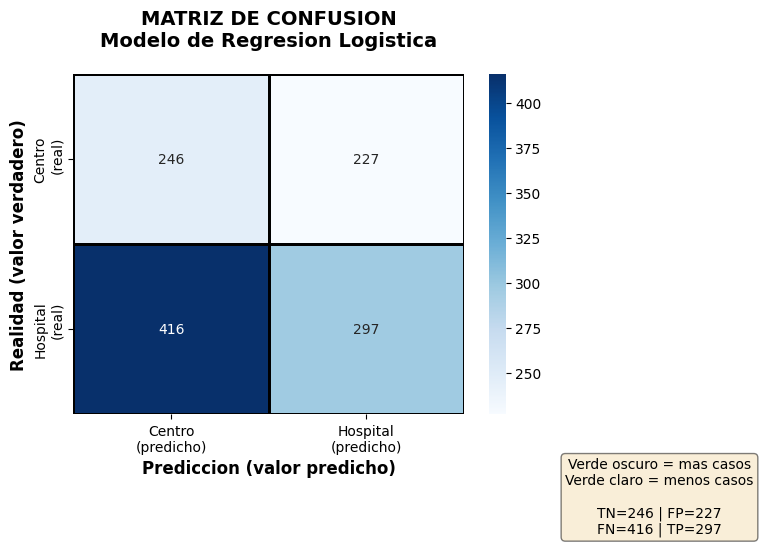


Graficamente:
  - Cuadrantes oscuros = muchos casos
  - Cuadrantes claros = pocos casos

OBSERVACION: El error FN=416 (abajo a la izquierda) es MAS oscuro
            que otros, indicando que es el error mas frecuente.


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# VISUALIZACION GRAFICA DE LA MATRIZ DE CONFUSION


# Crear figura
fig, ax = plt.subplots(figsize=(8, 6))

# Datos de la matriz
datos_matriz = matriz_confusion

# Etiquetas a utilizar en el heatmap
etiquetas_prediccion = ['Centro\n(predicho)', 'Hospital\n(predicho)']
etiquetas_real = ['Centro\n(real)', 'Hospital\n(real)']

# Crear heatmap
sns.heatmap(
    datos_matriz, 
    annot=True,  # Mostrar numeros
    fmt='d',     # Formato entero
    cmap='Blues',  # Palette azul
    cbar=True,   # Mostrar barra de color
    ax=ax,
    xticklabels=etiquetas_prediccion,
    yticklabels=etiquetas_real,
    linewidths=2,
    linecolor='black'
)

# Titulos y etiquetas
ax.set_title('MATRIZ DE CONFUSION\nModelo de Regresion Logistica', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Realidad (valor verdadero)', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediccion (valor predicho)', fontsize=12, fontweight='bold')

# Agregar texto explicativo
textstr = (
    'Verde oscuro = mas casos\n'
    'Verde claro = menos casos\n\n'
    'TN=246 | FP=227\n'
    'FN=416 | TP=297'
)
ax.text(1.5, -0.35, textstr, fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.show()

print('\nGraficamente:')
print('  - Cuadrantes oscuros = muchos casos')
print('  - Cuadrantes claros = pocos casos')
print('\nOBSERVACION: El error FN=416 (abajo a la izquierda) es MAS oscuro')
print('            que otros, indicando que es el error mas frecuente.')


## Como explicarlo al docente (guion breve)
1. **Problema**: predecir si un ingreso va a `Hospital` o `Centro de Salud`.
2. **Variables usadas**: `Causa` y `FechaAtencionTexto` (convertida a dia, mes y anio).
3. **Modelo elegido**: Regresion Logistica, porque el resultado tiene 2 clases y permite interpretar coeficientes.
4. **Preparacion de datos**: conversion de categorias a formato numerico con `OneHotEncoder`.
5. **Evaluacion**: separamos entrenamiento/prueba y medimos AUC + matriz de confusion.
6. **Hallazgo principal**: el AUC quedo cercano a 0.50, por lo que con estas variables la separacion entre clases es baja.
7. **Interpretacion de influencia**:
   - Coeficiente positivo: mayor probabilidad de `Hospital`.
   - Coeficiente negativo: mayor probabilidad de `Centro de Salud`.
8. **Mejora futura**: limpiar textos de `Causa` y agregar mas variables clinicas para mejorar capacidad explicativa.

## Analisis final (cumplimiento paso a paso)

### Paso 1. Objetivo del analisis
Determinar si la **causa de ingreso** y la **fecha de atencion** ayudan a explicar el **tipo de establecimiento** (`Hospital` vs `Centro de Salud`).

### Paso 2. Analisis descriptivo solicitado
En esta seccion se resume:
1. Frecuencia de causas de ingreso.
2. Evolucion temporal de atenciones por mes.
3. Distribucion por tipo de establecimiento.
4. Relacion entre causa y tipo de establecimiento.

### Paso 3. Modelado explicativo
Se usa **Regresion Logistica** con variables categoricas (`Causa`, dia de semana, mes, anio), codificadas con `OneHotEncoder`.

### Paso 4. Evaluacion del modelo
Se reportan metricas: **AUC**, **accuracy**, **precision**, **recall**, **F1**, matriz de confusion y curva ROC.

### Paso 5. Conclusion para exposicion
Si AUC queda cerca de 0.50, se concluye que con estas variables la capacidad predictiva es baja, y eso es un hallazgo valido del analisis.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    classification_report,
)

# PREPARACION DE DATOS PARA GRAFICOS Y EVALUACION

causas_top = (
    df['Causa']
    .astype(str)
    .str.strip()
    .replace({'': np.nan})
    .dropna()
    .value_counts()
    .head(10)
)

fechas = pd.to_datetime(df['FechaAtencionTexto'], format='%d-%m-%Y', errors='coerce')
atenciones_mes = fechas.dt.to_period('M').value_counts().sort_index()

tipo_est = (
    df['TipoEstablecimiento']
    .astype(str)
    .str.strip()
    .replace({'': np.nan})
    .dropna()
    .value_counts()
)

top8 = causas_top.head(8).index
tabla_relacion = pd.crosstab(
    df['Causa'].astype(str).str.strip(),
    df['TipoEstablecimiento'].astype(str).str.strip(),
    normalize='index'
).loc[top8] * 100

print('Preparacion lista: ahora ejecuta los bloques de graficos por separado.')

Preparacion lista: ahora ejecuta los bloques de graficos por separado.


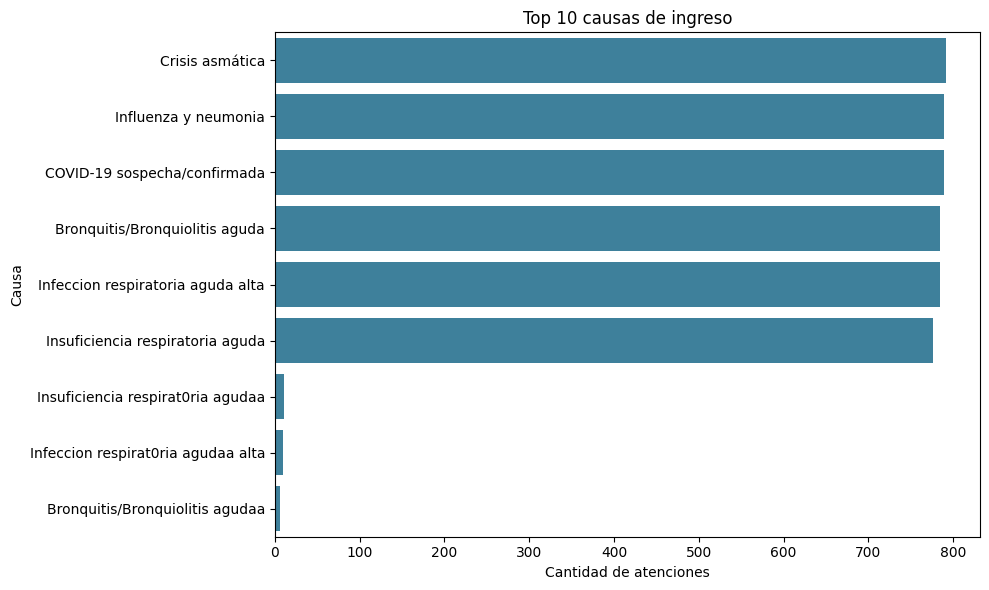

In [15]:
# GRAFICO 1: Top 10 causas de ingreso
plt.figure(figsize=(10, 6))
sns.barplot(x=causas_top.values, y=causas_top.index, color='#2E86AB')
plt.title('Top 10 causas de ingreso')
plt.xlabel('Cantidad de atenciones')
plt.ylabel('Causa')
plt.tight_layout()
plt.show()

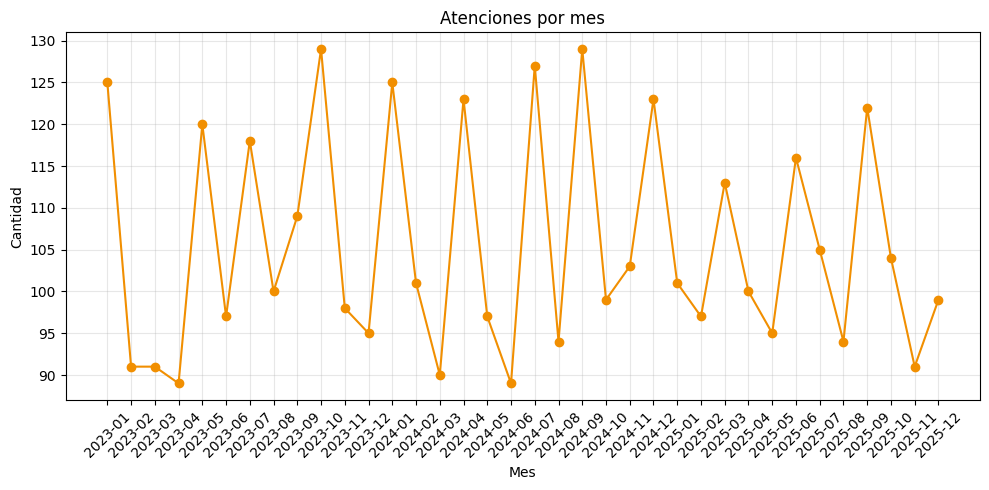

In [18]:
# GRAFICO 2: Atenciones por mes
plt.figure(figsize=(10, 5))
plt.plot(atenciones_mes.index.astype(str), atenciones_mes.values, marker='o', color='#F18F01')
plt.title('Atenciones por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

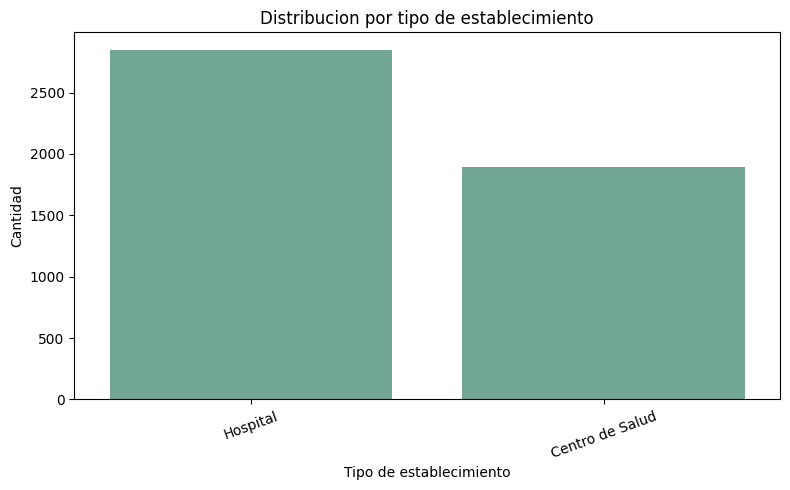

In [19]:
# GRAFICO 3: Distribucion por tipo de establecimiento
plt.figure(figsize=(8, 5))
sns.barplot(x=tipo_est.index, y=tipo_est.values, color='#6AAE9B')
plt.title('Distribucion por tipo de establecimiento')
plt.xlabel('Tipo de establecimiento')
plt.ylabel('Cantidad')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

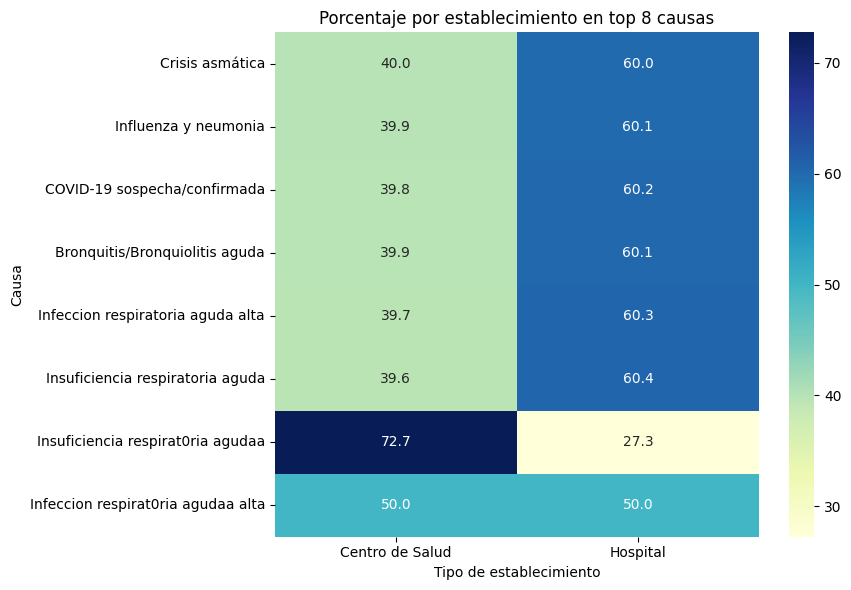

In [20]:
# GRAFICO 4: Relacion causa vs tipo de establecimiento (heatmap)
plt.figure(figsize=(9, 6))
sns.heatmap(tabla_relacion, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Porcentaje por establecimiento en top 8 causas')
plt.xlabel('Tipo de establecimiento')
plt.ylabel('Causa')
plt.tight_layout()
plt.show()

In [21]:
# BLOQUE DE METRICAS (sin grafico)
print('RESUMEN DESCRIPTIVO')
print('- Top causa:', causas_top.index[0], '| casos =', int(causas_top.iloc[0]))
print('- Tipo mas frecuente:', tipo_est.index[0], '| casos =', int(tipo_est.iloc[0]))
print('- Rango temporal:', atenciones_mes.index.min(), 'a', atenciones_mes.index.max())

accuracy = accuracy_score(y_prueba, predicciones_prueba)
precision = precision_score(y_prueba, predicciones_prueba, zero_division=0)
recall = recall_score(y_prueba, predicciones_prueba, zero_division=0)
f1 = f1_score(y_prueba, predicciones_prueba, zero_division=0)

TN, FP, FN, TP = matriz_confusion.ravel()

print('\nEVALUACION DEL MODELO')
print(f'- AUC: {metrica_auc:.4f}')
print(f'- Accuracy: {accuracy:.4f}')
print(f'- Precision (Hospital): {precision:.4f}')
print(f'- Recall (Hospital): {recall:.4f}')
print(f'- F1-score (Hospital): {f1:.4f}')
print(f'- Matriz confusion [[TN, FP], [FN, TP]]: {matriz_confusion.tolist()}')

print('\nINTERPRETACION DE LA MATRIZ DE CONFUSION')
print(f'- TN={TN}: Centro correctamente clasificado como Centro')
print(f'- FP={FP}: Centro clasificado por error como Hospital')
print(f'- FN={FN}: Hospital clasificado por error como Centro')
print(f'- TP={TP}: Hospital correctamente clasificado como Hospital')

print('\nReporte de clasificacion completo:')
print(classification_report(y_prueba, predicciones_prueba, target_names=['Centro de Salud', 'Hospital']))

print('CONCLUSION TECNICA')
if metrica_auc < 0.6:
    print('- El poder discriminativo del modelo es bajo con las variables actuales (causa y fecha).')
    print('- Recomendacion: agregar variables clinicas y mejorar calidad/normalizacion de textos de Causa.')
else:
    print('- El modelo muestra capacidad de discriminacion util para apoyar decisiones.')

RESUMEN DESCRIPTIVO
- Top causa: Crisis asmática | casos = 792
- Tipo mas frecuente: Hospital | casos = 2849
- Rango temporal: 2023-01 a 2025-12

EVALUACION DEL MODELO
- AUC: 0.4474
- Accuracy: 0.4578
- Precision (Hospital): 0.5668
- Recall (Hospital): 0.4165
- F1-score (Hospital): 0.4802
- Matriz confusion [[TN, FP], [FN, TP]]: [[246, 227], [416, 297]]

INTERPRETACION DE LA MATRIZ DE CONFUSION
- TN=246: Centro correctamente clasificado como Centro
- FP=227: Centro clasificado por error como Hospital
- FN=416: Hospital clasificado por error como Centro
- TP=297: Hospital correctamente clasificado como Hospital

Reporte de clasificacion completo:
                 precision    recall  f1-score   support

Centro de Salud       0.37      0.52      0.43       473
       Hospital       0.57      0.42      0.48       713

       accuracy                           0.46      1186
      macro avg       0.47      0.47      0.46      1186
   weighted avg       0.49      0.46      0.46      1186

C

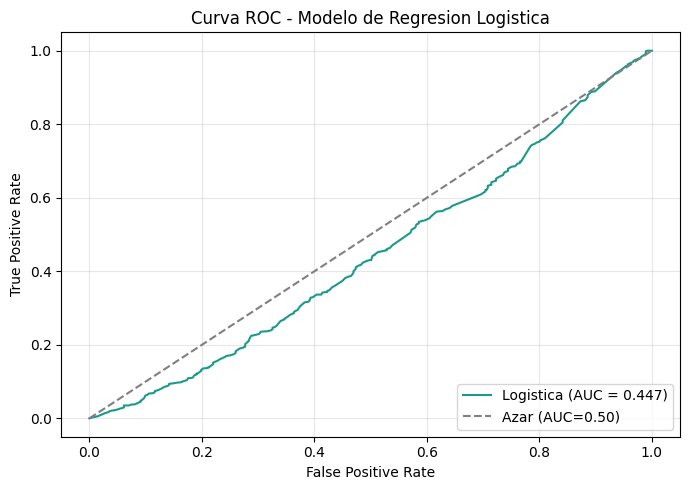

In [22]:
# GRAFICO 5: Curva ROC
fpr, tpr, _ = roc_curve(y_prueba, probabilidades_prueba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistica (AUC = {roc_auc:.3f})', color='#1B998B')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Azar (AUC=0.50)')
plt.title('Curva ROC - Modelo de Regresion Logistica')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()